In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots display clearly inside the notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)

# Load the dataset from the current directory
df = pd.read_csv("08-seismic_activity_svm.csv")

# 1. Display the first 5 rows of the dataset
print("--- FIRST 5 ROWS ---")
display(df.head())

--- FIRST 5 ROWS ---


,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [2]:
# 2. Check data types and whether there are any missing (null) values
print("\n--- DATASET INFORMATION (INFO) ---")
df.info()

# 3. Count the total number of missing (NaN) values in each column
print("\n--- MISSING VALUES CHECK ---")
print(df.isnull().sum())

# 4. Display the statistical summary of numerical columns
# (.T transposes the table, making it easier to read)
print("\n--- STATISTICAL SUMMARY ---")
display(df.describe().T)


--- DATASET INFORMATION (INFO) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB

--- MISSING VALUES CHECK ---
underground_wave_energy     0
vibration_axis_variation    0
seismic_event_detected      0
dtype: int64

--- STATISTICAL SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
underground_wave_energy,400.0,0.000000e+00,7.719350,-9.999954,-6.134779,0.0,6.134779,9.999954
vibration_axis_variation,400.0,8.881784e-18,1.751650,-3.000000,-1.500000,0.0,1.500000,3.000000
seismic_event_detected,400.0,5.000000e-01,0.500626,0.000000,0.000000,0.5,1.000000,1.000000


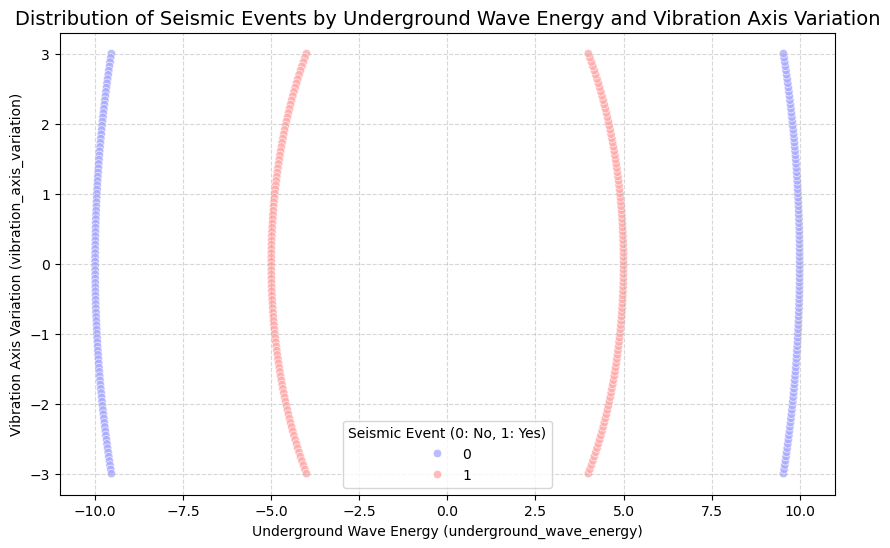

In [3]:
# Create a scatter plot with colors representing the different classes (hue)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='underground_wave_energy',
    y='vibration_axis_variation',
    hue='seismic_event_detected',
    palette='bwr',  # Blue (0) and Red (1) color palette
    alpha=0.8       # Slight transparency makes overlapping points easier to see
)

plt.title("Distribution of Seismic Events by Underground Wave Energy and Vibration Axis Variation", fontsize=14)
plt.xlabel("Underground Wave Energy (underground_wave_energy)")
plt.ylabel("Vibration Axis Variation (vibration_axis_variation)")
plt.legend(title="Seismic Event (0: No, 1: Yes)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

# Separate the independent (X) and dependent (y) variables
X = df[['underground_wave_energy', 'vibration_axis_variation']].values
y = df['seismic_event_detected'].values

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize the features
# Fit only on the training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

# In PyTorch, the target variable should have the shape (N, 1),
# so we use .view(-1, 1)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

print("Training set shape:", X_train_tensor.shape)
print("Test set shape:", X_test_tensor.shape)

Training set shape: torch.Size([320, 2])
Test set shape: torch.Size([80, 2])


In [5]:
class SeismicClassifier(nn.Module):
    def __init__(self):
        super(SeismicClassifier, self).__init__()

        # Define the layers
        self.hidden1 = nn.Linear(2, 4)   # 2 Inputs -> 4 Neurons
        self.hidden2 = nn.Linear(4, 2)   # 4 Neurons -> 2 Neurons
        self.output = nn.Linear(2, 1)    # 2 Neurons -> 1 Output

        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        # Initialize the weights (He/Kaiming Initialization)
        self._init_weights()

    def _init_weights(self):
        # Kaiming (He) initialization for layers using ReLU
        nn.init.kaiming_normal_(self.hidden1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.hidden2.weight, nonlinearity='relu')

        # Xavier (Glorot) initialization for the output layer using Sigmoid
        nn.init.xavier_normal_(self.output.weight)

    def forward(self, x):
        # Forward propagation
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.sigmoid(self.output(x))
        return x

# Initialize the model
model = SeismicClassifier()

# Loss function: Binary Cross Entropy for binary classification
criterion = nn.BCELoss()

# Optimizer: Adam (A learning rate of 0.01 is a good starting point)
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)

SeismicClassifier(
  (hidden1): Linear(in_features=2, out_features=4, bias=True)
  (hidden2): Linear(in_features=4, out_features=2, bias=True)
  (output): Linear(in_features=2, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [6]:
import copy

epochs = 500          # Maximum number of training epochs
patience = 20         # Early stopping patience (stop if validation loss does not improve for 20 epochs)
best_val_loss = float('inf')
counter = 0
best_model_weights = None

# Store losses and accuracies for plotting later
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("🚀 Training has started...\n" + "-" * 50)

for epoch in range(epochs):

    # --- 1. TRAINING PHASE ---
    model.train()            # Set the model to training mode
    optimizer.zero_grad()    # Clear gradients from the previous iteration

    # Forward propagation (make predictions)
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)

    # Backward propagation and weight update (learning step)
    loss.backward()
    optimizer.step()

    # Save training metrics (loss and accuracy)
    train_losses.append(loss.item())
    predicted_classes = (y_pred >= 0.5).float()  # If probability >= 0.5 → class 1, otherwise class 0
    train_acc = (predicted_classes == y_train_tensor).sum().item() / len(y_train_tensor)
    train_accs.append(train_acc)

    # --- 2. VALIDATION (TEST) PHASE ---
    model.eval()             # Set the model to evaluation mode (Dropout would be disabled here)
    with torch.no_grad():    # No need to compute gradients during evaluation (saves memory)
        y_val_pred = model(X_test_tensor)
        val_loss = criterion(y_val_pred, y_test_tensor)
        val_losses.append(val_loss.item())

        val_predicted_classes = (y_val_pred >= 0.5).float()
        val_acc = (val_predicted_classes == y_test_tensor).sum().item() / len(y_test_tensor)
        val_accs.append(val_acc)

    # --- 3. EARLY STOPPING CHECK ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0  # Improvement found, reset the patience counter
        best_model_weights = copy.deepcopy(model.state_dict())  # Save the best model weights
    else:
        counter += 1  # No improvement, increase the patience counter

    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch [{epoch+1:3d}/{epochs}] | "
            f"Train Loss: {loss.item():.4f} - Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss.item():.4f} - Acc: {val_acc:.4f}"
        )

    # Stop training if patience has been exhausted
    if counter >= patience:
        print(
            f"\n🛑 Early stopping triggered! "
            f"Training stopped at epoch {epoch+1} before the model started overfitting."
        )
        break

# Restore the best model weights
if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print("\n✅ The best model weights have been successfully restored.")

🚀 Training has started...
--------------------------------------------------
Epoch [ 50/500] | Train Loss: 0.5910 - Acc: 0.6906 | Val Loss: 0.6437 - Acc: 0.5750
Epoch [100/500] | Train Loss: 0.3057 - Acc: 0.9344 | Val Loss: 0.3206 - Acc: 0.9250
Epoch [150/500] | Train Loss: 0.0386 - Acc: 1.0000 | Val Loss: 0.0438 - Acc: 1.0000
Epoch [200/500] | Train Loss: 0.0119 - Acc: 1.0000 | Val Loss: 0.0140 - Acc: 1.0000
Epoch [250/500] | Train Loss: 0.0059 - Acc: 1.0000 | Val Loss: 0.0071 - Acc: 1.0000
Epoch [300/500] | Train Loss: 0.0036 - Acc: 1.0000 | Val Loss: 0.0043 - Acc: 1.0000
Epoch [350/500] | Train Loss: 0.0025 - Acc: 1.0000 | Val Loss: 0.0030 - Acc: 1.0000
Epoch [400/500] | Train Loss: 0.0018 - Acc: 1.0000 | Val Loss: 0.0022 - Acc: 1.0000
Epoch [450/500] | Train Loss: 0.0014 - Acc: 1.0000 | Val Loss: 0.0016 - Acc: 1.0000
Epoch [500/500] | Train Loss: 0.0011 - Acc: 1.0000 | Val Loss: 0.0013 - Acc: 1.0000

✅ The best model weights have been successfully restored.


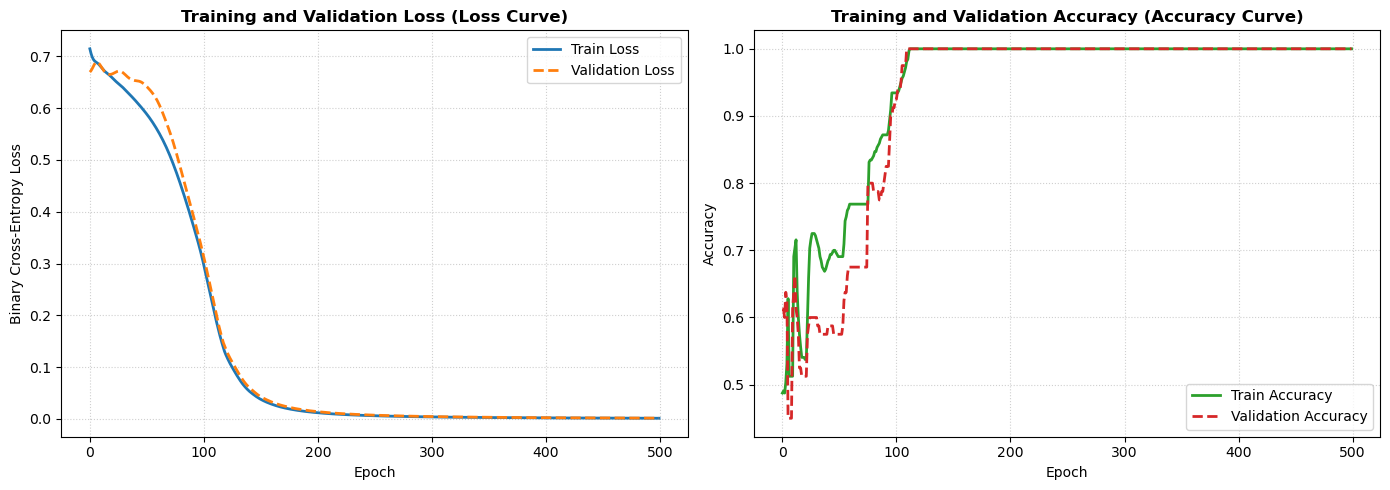

In [7]:
plt.figure(figsize=(14, 5))

# 1. Loss Curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Training and Validation Loss (Loss Curve)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 2. Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', color='#2ca02c', linewidth=2)
plt.plot(val_accs, label='Validation Accuracy', color='#d62728', linestyle='--', linewidth=2)
plt.title('Training and Validation Accuracy (Accuracy Curve)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

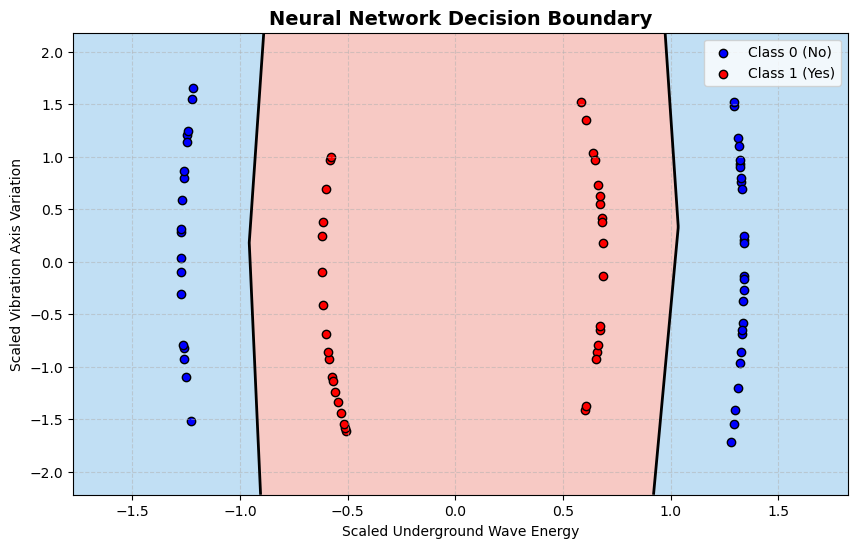

In [8]:
# Create a mesh grid for plotting the decision boundary
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Get predictions from the model for every point in the grid
grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
model.eval()
with torch.no_grad():
    Z = model(grid_tensor)
Z = Z.reshape(xx.shape).numpy()

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(
    xx, yy, Z,
    levels=[0, 0.5, 1],
    alpha=0.3,
    colors=['#3498db', '#e74c3c']
)
plt.contour(
    xx, yy, Z,
    levels=[0.5],
    colors='black',
    linewidths=2
)  # Decision boundary at probability = 0.5

# Overlay the actual test data points
plt.scatter(
    X_test_scaled[y_test == 0, 0],
    X_test_scaled[y_test == 0, 1],
    color='blue',
    label='Class 0 (No)',
    edgecolors='k'
)
plt.scatter(
    X_test_scaled[y_test == 1, 0],
    X_test_scaled[y_test == 1, 1],
    color='red',
    label='Class 1 (Yes)',
    edgecolors='k'
)

plt.title('Neural Network Decision Boundary', fontsize=14, fontweight='bold')
plt.xlabel('Scaled Underground Wave Energy')
plt.ylabel('Scaled Vibration Axis Variation')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 🌋 Seismic Activity Classification with Deep Learning (PyTorch)

## 📌 Project Overview
This project focuses on building a Binary Classification Neural Network from scratch using **PyTorch** to predict seismic activity based on underground wave features. The dataset presents a non-linearly separable pattern, making deep learning an ideal choice over linear classifiers.

---

## 📊 Dataset & Exploratory Data Analysis (EDA)
* **Total Samples:** 400 balanced samples (200 Class 0, 200 Class 1)
* **Features ($X$):**
  * `underground_wave_energy` (Float)
  * `vibration_axis_variation` (Float)
* **Target ($y$):** `seismic_event_detected` (Binary: 0 = No, 1 = Yes)
* **Data Characteristics:** Visually identified as non-linearly separable, with Class 1 forming an inner band flanked by Class 0 on both sides.

---

## 🛠️ Data Preprocessing & Pipeline
1. **Train/Test Split:** 80% Training ($N=320$) and 20% Testing ($N=80$).
2. **Feature Scaling:** Applied `StandardScaler` to normalize feature magnitudes.
3. **Tensor Conversion:** Converted processed NumPy arrays into PyTorch `FloatTensor` format.

---

## 🧠 Neural Network Architecture
A custom Multi-Layer Perceptron (MLP) built with `torch.nn.Module`: